In [1]:
!pip install -q imbalanced-learn
!pip install -q deap
!pip install -q xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score
from deap import base, creator, tools, algorithms
import random
import time
import warnings

In [3]:
# Suppress warnings
warnings.filterwarnings("ignore")

In [5]:
# Load dataset
df = pd.read_csv('/content/IoT Network Intrusion Dataset.csv')
print("✅ Dataset Loaded")

# Shape and structure
print(f"🔹 Shape: {df.shape}")
print("🔹 First few rows:")
display(df.head())

✅ Dataset Loaded
🔹 Shape: (625783, 86)
🔹 First few rows:


,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Cat,Sub_Cat
0,192.168.0.13-192.168.0.16-10000-10101-17,192.168.0.13,10000,192.168.0.16,10101,17,25/07/2019 03:25:53 AM,75,1,1,...,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Anomaly,Mirai,Mirai-Ackflooding
1,192.168.0.13-222.160.179.132-554-2179-6,222.160.179.132,2179,192.168.0.13,554,6,26/05/2019 10:11:06 PM,5310,1,2,...,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,Anomaly,DoS,DoS-Synflooding
2,192.168.0.13-192.168.0.16-9020-52727-6,192.168.0.16,52727,192.168.0.13,9020,6,11/07/2019 01:24:48 AM,141,0,3,...,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Anomaly,Scan,Scan Port OS
3,192.168.0.13-192.168.0.16-9020-52964-6,192.168.0.16,52964,192.168.0.13,9020,6,04/09/2019 03:58:17 AM,151,0,2,...,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Anomaly,Mirai,Mirai-Hostbruteforceg
4,192.168.0.1-239.255.255.250-36763-1900-17,192.168.0.1,36763,239.255.255.250,1900,17,10/09/2019 01:41:18 AM,153,2,1,...,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Anomaly,Mirai,Mirai-Hostbruteforceg


In [6]:
# Drop unwanted columns
drop_cols = ['Flow_ID', 'Src_IP', 'Dst_IP', 'Timestamp', 'Label', 'Sub_Cat']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True, errors='ignore')

# Handle NaN and infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

print(f"\n✅ Cleaned Dataset Shape: {df.shape}")
print("🔹 Data Types:")
print(df.dtypes.value_counts())


✅ Cleaned Dataset Shape: (261543, 80)
🔹 Data Types:
float64    45
int64      34
object      1
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [9]:
# Encode labels initially
le = LabelEncoder()
df['Cat'] = le.fit_transform(df['Cat'])

# Features & Target (initial assignment)
X = df.drop('Cat', axis=1)
y = df['Cat']

# Identify and remove minority classes (classes with only 1 sample)
# This is necessary for stratified train_test_split
class_counts = y.value_counts()
minority_classes = class_counts[class_counts < 2].index

if not minority_classes.empty:
    print(f"⚠️ Removing minority classes with < 2 samples: {le.inverse_transform(minority_classes).tolist()}")
    df = df[~df['Cat'].isin(minority_classes)]

    # Re-encode 'Cat' column after removing minority classes to ensure contiguous labels (0 to N-1)
    le = LabelEncoder() # Reinitialize to fit on the new set of classes
    df['Cat'] = le.fit_transform(df['Cat'])

# Re-assign Features & Target after filtering
X = df.drop('Cat', axis=1)
y = df['Cat']

print(f"✅ Final Dataset Shape after removing minority classes: {df.shape}")

✅ Final Dataset Shape after removing minority classes: (261543, 80)


In [10]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

Class distribution before SMOTE:
Cat
2    114666
0     47490
3     22024
4     13019
1     12035
Name: count, dtype: int64


In [12]:
# Balance only training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("✅ Data Balanced with SMOTE")
print(f"🔹 X_train_bal: {X_train_bal.shape}")
print(f"🔹 y_train_bal: {np.bincount(y_train_bal)}")

✅ Data Balanced with SMOTE
🔹 X_train_bal: (573330, 79)
🔹 y_train_bal: [114666 114666 114666 114666 114666]


In [13]:
print("Class distribution after SMOTE:")
print(y_train_bal.value_counts())

Class distribution after SMOTE:
Cat
2    114666
4    114666
1    114666
3    114666
0    114666
Name: count, dtype: int64


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import accuracy_score, classification_report

models = {
    #'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42, early_stopping=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    #'ExtrasTreesClassifier' : ExtraTreesClassifier(n_estimators=200, random_state=42)
}

⏳ Running Optimized Genetic Algorithm...
✅ GA completed in 308.60 seconds
✅ GA Selected 12 Features:
['Src_Port', 'Dst_Port', 'Flow_Pkts/s', 'Flow_Duration', 'Flow_IAT_Max', 'Idle_Max', 'Init_Bwd_Win_Byts', 'Flow_IAT_Min', 'Bwd_IAT_Tot', 'Bwd_IAT_Mean', 'Subflow_Bwd_Byts', 'Pkt_Size_Avg']

📊 Classification Report (Hybrid Selected Features):


🧠 Model: Random Forest
🔹 Train Accuracy: 0.9995
🔹 Test Accuracy : 0.9674
🔸 Classification Report (Test):
                   precision    recall  f1-score   support

              DoS       1.00      1.00      1.00     11872
MITM ARP Spoofing       0.76      0.88      0.82      3009
            Mirai       0.99      0.97      0.98     28667
           Normal       0.99      0.98      0.99      5506
             Scan       0.87      0.91      0.89      3255

         accuracy                           0.97     52309
        macro avg       0.92      0.95      0.94     52309
     weighted avg       0.97      0.97      0.97     52309


🧠 Model: MLP
🔹 

,Train Accuracy,Test Accuracy,Gap
Random Forest,0.999506,0.967367,0.032139
KNN,0.969752,0.945784,0.023968
MLP,0.934736,0.911067,0.023669
XGBoost,0.967935,0.959280,0.008654


<Figure size 1000x600 with 0 Axes>

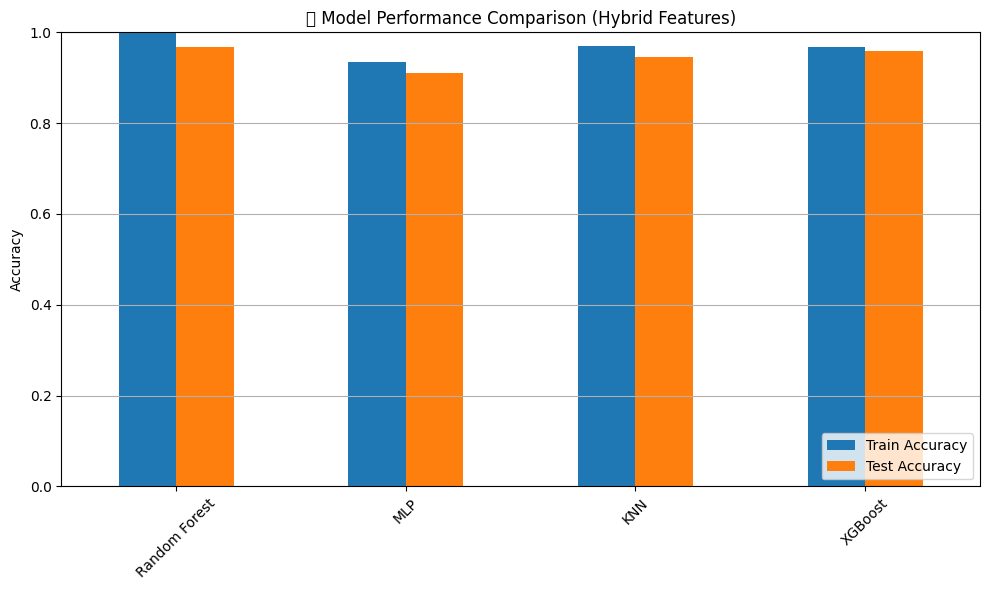

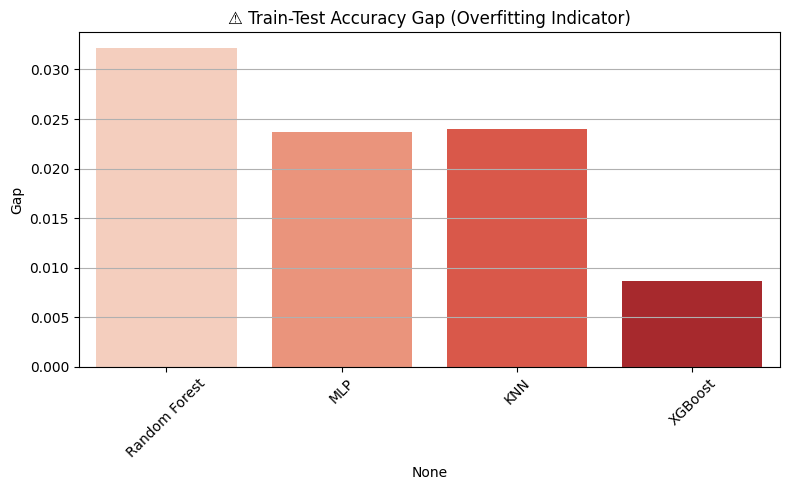

In [ ]:
# Step 1: Use only top 20 features from MI
# Ensure X_train_bal and y_train_bal are not empty
if X_train_bal.shape[0] > 0 and len(np.unique(y_train_bal)) > 1:
    mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_k_mi = 20  
    top_features = mi_series.head(top_k_mi).index.tolist()

    X_train_mi = X_train_bal[top_features]
    X_test_mi = X_test[top_features]
    K = 13  
    if not hasattr(creator, "FitnessMax"):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMax)
    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=top_k_mi)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def get_fitness(individual):
        if sum(individual) == 0:
            return 0.,
        idx = [i for i, bit in enumerate(individual) if bit == 1]
        X_sub = X_train_mi.iloc[:, idx]
        clf = DecisionTreeClassifier(max_depth=6, random_state=42)
        if X_sub.shape[0] > 0 and len(np.unique(y_train_bal)) > 1:
            scores = cross_val_score(clf, X_sub, y_train_bal, cv=2, scoring='accuracy')
            acc = scores.mean()
        else:
            acc = 0.0 
        penalty = 0.01 * (sum(individual) - K) ** 2
        return acc - penalty,

    toolbox.register("evaluate", get_fitness)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=2)

    pop = toolbox.population(n=15)  # Smaller population
    hof = tools.HallOfFame(1)

    start = time.time()
    print("⏳ Running Optimized Genetic Algorithm...")
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.3, ngen=6, halloffame=hof, verbose=False)  # Fewer generations
    end = time.time()
    print(f"✅ GA completed in {(end - start):.2f} seconds")

    # Selected Features
    selected_idx = [i for i, bit in enumerate(hof[0]) if bit == 1]
    selected_features = [top_features[i] for i in selected_idx]
    print(f"✅ GA Selected {len(selected_features)} Features:\n{selected_features}")

    # Final selected feature dataset
    X_train_sel = X_train_bal[selected_features]
    X_test_sel = X_test[selected_features]

    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    X_train_sel_scaled = scaler.fit_transform(X_train_sel)
    X_test_sel_scaled = scaler.transform(X_test_sel)


    from sklearn.metrics import accuracy_score, classification_report

    hybrid_results = {}
    print("\n📊 Classification Report (Hybrid Selected Features):\n")

    for name, model in models.items():
        if name == "MLP":
            model.fit(X_train_sel_scaled, y_train_bal)
            y_train_pred = model.predict(X_train_sel_scaled)
            y_test_pred = model.predict(X_test_sel_scaled)
        else:
            model.fit(X_train_sel, y_train_bal)
            y_train_pred = model.predict(X_train_sel)
            y_test_pred = model.predict(X_test_sel)

        # model.fit(X_train_sel, y_train_bal)

        # y_train_pred = model.predict(X_train_sel)
        # y_test_pred = model.predict(X_test_sel)

        train_acc = accuracy_score(y_train_bal, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        hybrid_results[name] = {
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Classification Report": classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_], output_dict=True)
        }

        print(f"\n🧠 Model: {name}")
        print(f"🔹 Train Accuracy: {train_acc:.4f}")
        print(f"🔹 Test Accuracy : {test_acc:.4f}")
        print("🔸 Classification Report (Test):")
        print(classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_]))

    # Create Overfitting Gap Table
    overfit_df = pd.DataFrame({
        model: {
            "Train Accuracy": vals["Train Accuracy"],
            "Test Accuracy": vals["Test Accuracy"],
            "Gap": vals["Train Accuracy"] - vals["Test Accuracy"]
        }
        for model, vals in hybrid_results.items()
    }).T

    print("\n📉 Overfitting Check (Train-Test Accuracy Gap):")
    display(overfit_df.sort_values(by="Gap", ascending=False))

    import matplotlib.pyplot as plt
    import seaborn as sns

    # Barplot of Train/Test Accuracy
    plt.figure(figsize=(10,6))
    overfit_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(10,6))
    plt.title("🔍 Model Performance Comparison (Hybrid Features)")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # Gap Visualization
    plt.figure(figsize=(8,5))
    sns.barplot(x=overfit_df.index, y=overfit_df['Gap'], palette="Reds")
    plt.title("⚠️ Train-Test Accuracy Gap (Overfitting Indicator)")
    plt.ylabel("Gap")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("❗ Skipping feature selection and model training due to insufficient data or classes after filtering minority classes.")